# MITGCM Time Scale Analysis in isopycnal coordinates

**Purpose**: Code for preforming the time scale analysis. I will compute the decorrelation time scale for a subset of the model domain at each grid point. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
import matplotlib as mpl

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize
from spectra import spectrum1D_frequency, spectral_slope
from lsf import unweighted_lsf, compute_amp_phase, compute_amp_phase_unc, detrend
from structure_functions import compute_structure_function
from var_analysis import variance_scale_analysis_1D_masked

Set data analysis parameters

In [3]:
# Set processing parameters
option_plot          = 0          # Specifies if supplementary plots are plotted
option_var           = 'sal'     # Specifies which variable will analyzed. Options include: temp, sal, depth
option_bin           = 0

# Set time and space parameters
T            = 1*(60)*(60)                   # Spcifies the time interval for model run. Units: seconds
estimator    = 'biased'                      # Specifies the approach for estimating the autocorrelation function    
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs_server/mitgcm/scale_analysis/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 16

Load mitgcm data netcdf files 

In [4]:
#--- MITgcm Data ---# 
filename = PATH + "mitgcm_intermediate_data_TSD_hrly_ts_profiles.nc"
nc = Dataset(filename, 'r')

# Extract data variables
iso1 = nc.variables['isopycnal1'][:]
iso2 = nc.variables['isopycnal2'][:]
iso3 = nc.variables['isopycnal3'][:]
lon   = nc.variables['LON'][:]
lat   = nc.variables['LAT'][:]
time  =  num2date(nc.variables['time'][:], nc.variables['time'].units)

if option_var == 'temp':
    data1 = nc.variables['CTemp1_sig'][:]
    data2 = nc.variables['CTemp2_sig'][:]
    data3 = nc.variables['CTemp3_sig'][:]
elif option_var == 'sal':
    data1 = nc.variables['ASal1_sig'][:]
    data2 = nc.variables['ASal2_sig'][:]
    data3 = nc.variables['ASal3_sig'][:]
elif option_var == 'depth':
    data1 = nc.variables['Z1_sig'][:]
    data2 = nc.variables['Z2_sig'][:]
    data3 = nc.variables['Z3_sig'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

Plot profile time series and time averaged profile

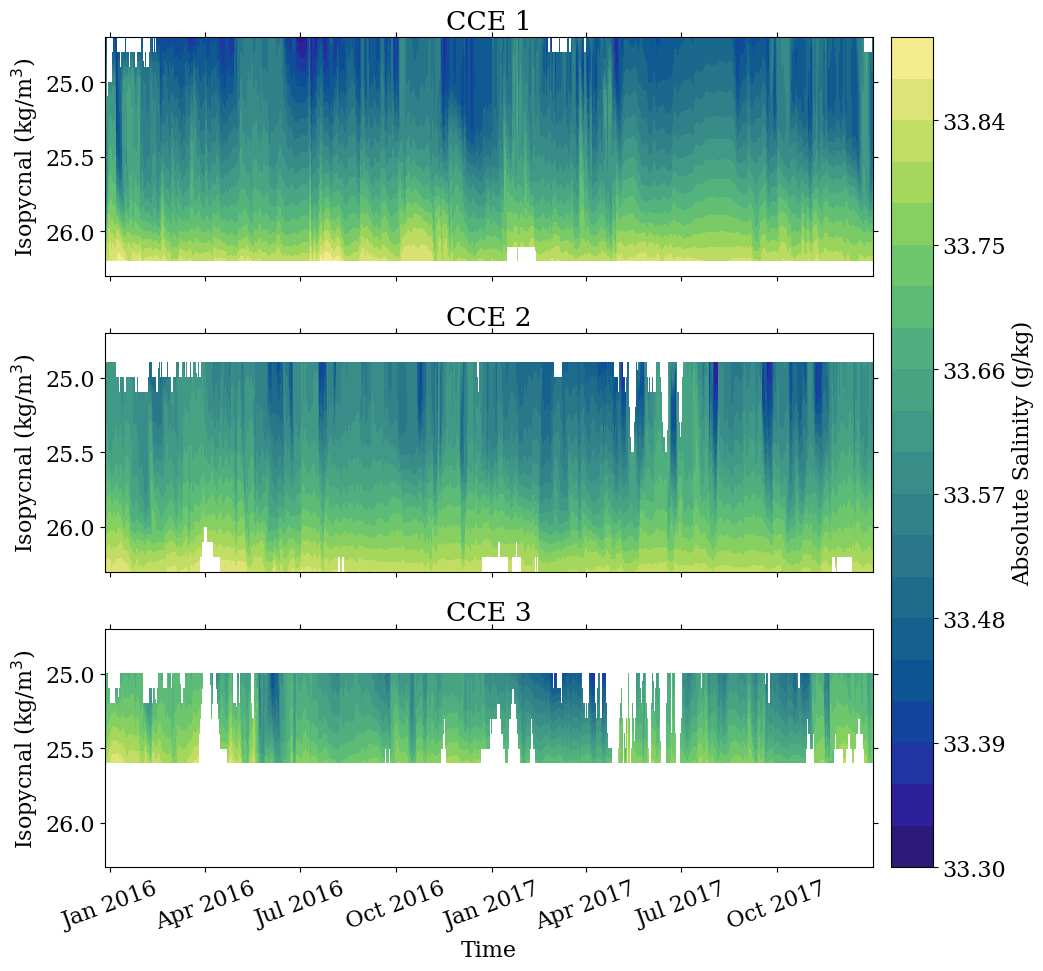

In [5]:
# Set the fontsize
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})
mpl.rcParams['text.usetex'] = False

# Set plotting parameters
if option_var == 'temp':
    label = r'Conservative Temperature (deg C)'
    cmap = cmo.thermal
elif option_var == 'sal':
    label = r'Absolute Salinity (g/kg)'
    cmap = cmo.haline
elif option_var == 'depth': 
    label = r'Isopycnal Depth (m)'
    cmap = cmo.deep

# Create figure
fig,axes = plt.subplots(3,1,figsize=(12, 10))
ax1,ax2,ax3 =  axes.flatten()

# Loop through axes
for i, ax in enumerate(axes):

    # Plot data
    if i == 0: 
        cf = ax.contourf(time_dt,iso1,data1, levels=20, cmap=cmap) #, vmin=, vmax=1.2)
    elif i == 1: 
        cf = ax.contourf(time_dt,iso2,data2, levels=20, cmap=cmap)
    else:
        cf = ax.contourf(time_dt,iso3,data3, levels=20, cmap=cmap)

    # Set axis attributes
    ax.set_title(f"CCE {i+1}")
    ax.set_ylim(24.7,26.3)
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.set_ylabel(r"Isopycnal (kg/m$^{3}$)")
    ax.tick_params(top=True, bottom=True, left=True, right=True,
                   direction='out', length=3.5)
    plt.setp(ax.get_xticklabels(), rotation=20)
    if (i == 0) | (i == 1):
        ax.set_xticklabels([])
    if i == 2:
        ax.set_xlabel("Time")

# Adjust layout before adding colorbar
plt.tight_layout()
fig.subplots_adjust(right=0.87)  # Make space on the right side

# Add shared colorbar
cbar = fig.colorbar(cf, ax=axes, location='right', pad=0.02)
cbar.set_label(label)

# Show figure
plt.show()

Compute temporal decorrelation scale over the full 2-year period 

In [6]:
# Set parameters
nsite = 3
ntime = data1.shape[1]
niso1, niso2, niso3 = data1.shape[0], data2.shape[0], data3.shape[0]
lag = ntime                                                  # Specifies the number of lags in the autocorrelation function
w1, w2 = [(2*np.pi)/31557600, (1/2)*(2*np.pi)/31557600]      # Specifies the radian Frequency for annual and semi-annual cycles. Units: rad/sec

# Compute scales array for variance analysis and convert to hours (number of samples)
scales_days = np.logspace(np.log10(0.5),np.log10(365),40)    # units: days
scales = scales_days*24                                      # units: # of samples

# Convert to interger values 
nscales = len(scales)
scales_int = np.array([int(scales[i]) for i in range(nscales)])

# Compute the elapsed time from beginning of time series (units: seconds)
t0 = time[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time])

#-------------------------------------------------------#
# CCE 1 Mooring
#-------------------------------------------------------#

# Initialize arrays 
autocorr1        = np.zeros((ntime,niso1))
struct1          = np.zeros((ntime,niso1))
time_scale1      = np.zeros((ntime,niso1))
Lt1              = np.zeros((niso1))
V1               = np.zeros((nscales,niso1))
L1               = np.zeros((nscales,niso1))
p1               = np.zeros((niso1))

# Set counter
cn_iso = 0 

# Loop through isopycnal coordinates 
for it in range(0,niso1):

    # Set progress bar
    progress = (it) / (len(iso1))
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()
            
    # Initialize the ith isopycnal time series 
    data_ts = data1[it,:]

    # Skip depth if all values are masked
    if np.all(data_ts.mask):
        continue

    # Remove annual and semi-annual cycle 
    hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
    data_ts_rm = data_ts - hfit

    # Detrend data record 
    data_dt = detrend(data_ts_rm, time_elapsed, mean = 0)

    # Compute autocorrelation function
    autocorr1[:,cn_iso], _, _, _, time_scale1[:,cn_iso], _ = compute_autocorr_optimize(data_dt, time_elapsed, lag, estimator, 0)

    # Compute the decorrelation scale
    Lt1[cn_iso] = compute_decor_scale_optimize(autocorr1[:,cn_iso],time_scale1[:,cn_iso],T,'unbiased',0)

    # Compute scale variance and patchiness
    L1[:,cn_iso], V1[:,cn_iso], p1[cn_iso], _ = variance_scale_analysis_1D_masked(data_dt, scales=scales_int, fit_range=None, overlap=0.0, return_windows=False)

    # Set longitude counter
    cn_iso = cn_iso + 1

# Convert time scale to units of days
Lt1_days = Lt1*(1/60)*(1/60)*(1/24)

#-------------------------------------------------------#
# CCE 2 Mooring
#-------------------------------------------------------#

# Initialize arrays 
autocorr2        = np.zeros((ntime,niso2))
struct2          = np.zeros((ntime,niso2))
time_scale2      = np.zeros((ntime,niso2))
Lt2              = np.zeros((niso2))
V2               = np.zeros((nscales,niso2))
L2               = np.zeros((nscales,niso2))
p2               = np.zeros((niso2))

# Set counter
cn_iso = 0 

# Loop through depths 
for it in range(0,niso2):

    # Set progress bar
    progress = (it) / (len(iso2))
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()
            
    # Initialize the ith depth time series 
    data_ts = data2[it,:]

    # Skip depth if all values are masked
    if np.all(data_ts.mask):
        continue

    # Remove annual and semi-annual cycle 
    hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
    data_ts_rm = data_ts - hfit

    # Detrend data record 
    data_dt = detrend(data_ts_rm, time_elapsed, mean = 0)

    # Compute autocorrelation function
    autocorr2[:,cn_iso], _, _, _, time_scale2[:,cn_iso], _ = compute_autocorr_optimize(data_dt, time_elapsed, lag, estimator, 0)

    # Compute the decorrelation scale
    Lt2[cn_iso] = compute_decor_scale_optimize(autocorr2[:,cn_iso],time_scale1[:,cn_iso],T,'unbiased',0)

    # Compute scale variance and patchiness
    L2[:,cn_iso], V2[:,cn_iso], p2[cn_iso], _ = variance_scale_analysis_1D_masked(data_dt, scales=scales_int, fit_range=None, overlap=0.0, return_windows=False)

    # Set longitude counter
    cn_iso = cn_iso + 1

# Convert time scale to units of days
Lt2_days = Lt2*(1/60)*(1/60)*(1/24)

#-------------------------------------------------------#
# CCE 3 Mooring
#-------------------------------------------------------#

# Initialize arrays 
autocorr3        = np.zeros((ntime,niso3))
struct3          = np.zeros((ntime,niso3))
time_scale3      = np.zeros((ntime,niso3))
Lt3              = np.zeros((niso3))
V3               = np.zeros((nscales,niso3))
L3               = np.zeros((nscales,niso3))
p3               = np.zeros((niso3))

# Set counter
cn_iso = 0 

# Loop through depths 
for it in range(0,niso3):

    # Set progress bar
    progress = (it) / (len(iso3))
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()
            
    # Initialize the ith depth time series 
    data_ts = data3[it,:]

    # Skip depth if all values are masked
    if np.all(data_ts.mask):
        continue

    # Remove annual and semi-annual cycle 
    hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
    data_ts_rm = data_ts - hfit

    # Detrend data record 
    data_dt = detrend(data_ts_rm, time_elapsed, mean = 0)

    # Compute autocorrelation function
    autocorr3[:,cn_iso], _, _, _, time_scale3[:,cn_iso], _ = compute_autocorr_optimize(data_dt, time_elapsed, lag, estimator, 0)

    # Compute the decorrelation scale
    Lt3[cn_iso] = compute_decor_scale_optimize(autocorr3[:,cn_iso],time_scale3[:,cn_iso],T,'unbiased',0)

    # Compute scale variance and patchiness
    L3[:,cn_iso], V3[:,cn_iso], p3[cn_iso], _ = variance_scale_analysis_1D_masked(data_dt, scales=scales_int, fit_range=None, overlap=0.0, return_windows=False)

    # Set longitude counter
    cn_iso = cn_iso + 1

# Convert time scale to units of days
Lt3_days = Lt3*(1/60)*(1/60)*(1/24)

# Mask fill values (zeros)
Lt1_days_m = np.ma.masked_where(Lt1_days == 0, Lt1_days)
Lt2_days_m = np.ma.masked_where(Lt2_days == 0, Lt2_days)
Lt3_days_m = np.ma.masked_where(Lt3_days == 0, Lt3_days)

Progress: 85.7%

Compute the mean and variance depth profile for the data

In [7]:
# Compute the time mean, standard deviation, and variance profiles along isopycnals for each site
mean_profile1 = np.ma.mean(data1,axis=1) 
mean_profile2 = np.ma.mean(data2,axis=1) 
mean_profile3 = np.ma.mean(data3,axis=1) 

std_profile1 = np.ma.std(data1,axis=1,ddof=1)
std_profile2 = np.ma.std(data2,axis=1,ddof=1)
std_profile3 = np.ma.std(data3,axis=1,ddof=1)

var_profile1 = np.ma.var(data1,axis=1,ddof=1)
var_profile2 = np.ma.var(data2,axis=1,ddof=1)
var_profile3 = np.ma.var(data3,axis=1,ddof=1)

# Compute the number of degrees of freedom at each site
T_days = T*(1/60)*(1/60)*(1/24)
n_d1, n_d2, n_d3 = Lt1_days_m/T_days, Lt2_days_m/T_days, Lt3_days_m/T_days
Neff1 = ntime/(n_d1)
Neff2 = ntime/(n_d2)
Neff3 = ntime/(n_d3)

# Compute the standard error of the mean and variance
stdm1_profile = std_profile1/np.sqrt(Neff1)
stdm2_profile = std_profile2/np.sqrt(Neff2)
stdm3_profile = std_profile3/np.sqrt(Neff3)

stdv1_profile = var_profile1 * np.sqrt(2/(Neff1-1))
stdv2_profile = var_profile2 * np.sqrt(2/(Neff2-1))
stdv3_profile = var_profile3 * np.sqrt(2/(Neff3-1))


Plot the model's decorrelation scale at the three locations

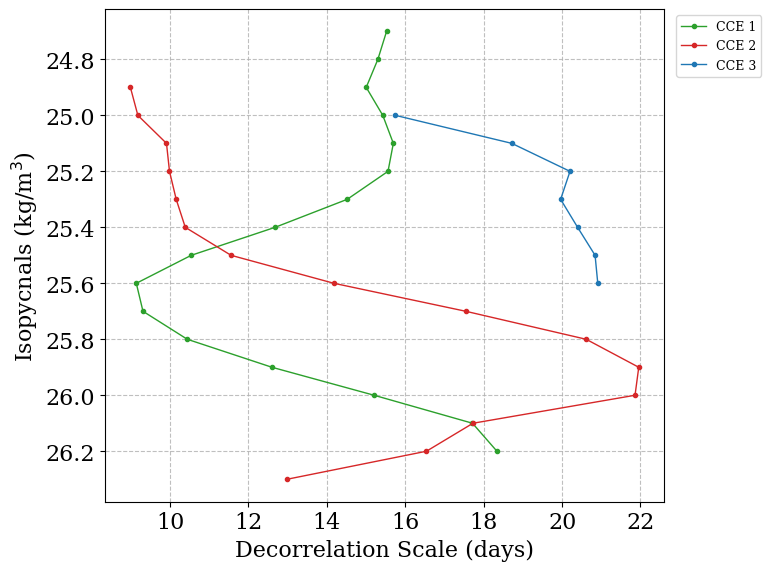

In [8]:
# Create the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Plot the depth-dependent decorrelation time scale
ax.plot(Lt1_days_m, iso1, '.-', color='tab:green', linewidth=1,label='CCE 1')
ax.plot(Lt2_days_m, iso2, '.-', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(Lt3_days_m, iso3, '.-', color='tab:blue', linewidth=1, label='CCE 3')

# Set figure attributes
ax.set_xlabel(r'Decorrelation Scale (days)')
ax.set_ylabel(r'Isopycnals (kg/m$^{3}$)')
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Reverse the direction of the x-axis 
ax.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

Plot the time averaged profiles 

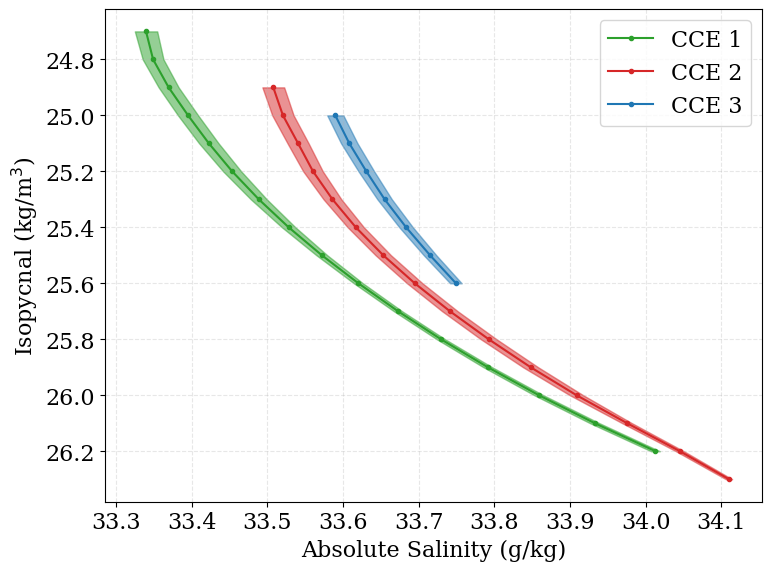

In [9]:
# Create figure
fig,ax = plt.subplots(1,1,figsize=(8, 6))

# Plot mean profiles for each mooring
ax.plot(mean_profile1,iso1,'.-',color='tab:green',label='CCE 1')
ax.plot(mean_profile2,iso2,'.-',color='tab:red',label='CCE 2')
ax.plot(mean_profile3,iso3,'.-',color='tab:blue',label='CCE 3')

# Plot standard error of the mean profiles for each mooring
ax.fill_betweenx(iso1, mean_profile1 - stdm1_profile, mean_profile1 + stdm1_profile, color='tab:green', alpha=0.5)
ax.fill_betweenx(iso2, mean_profile2 - stdm2_profile, mean_profile2 + stdm2_profile, color='tab:red', alpha=0.5)
ax.fill_betweenx(iso3, mean_profile3 - stdm3_profile, mean_profile3 + stdm3_profile, color='tab:blue', alpha=0.5)

# Set axis attributes
ax.set_xlabel(label)
ax.set_ylabel(r"Isopycnal (kg/m$^{3}$)")
ax.invert_yaxis()
ax.legend()
ax.grid(True,linestyle='--',alpha=0.3)

# Show figure
plt.tight_layout()
plt.show()

Plot the variance along isopycnals

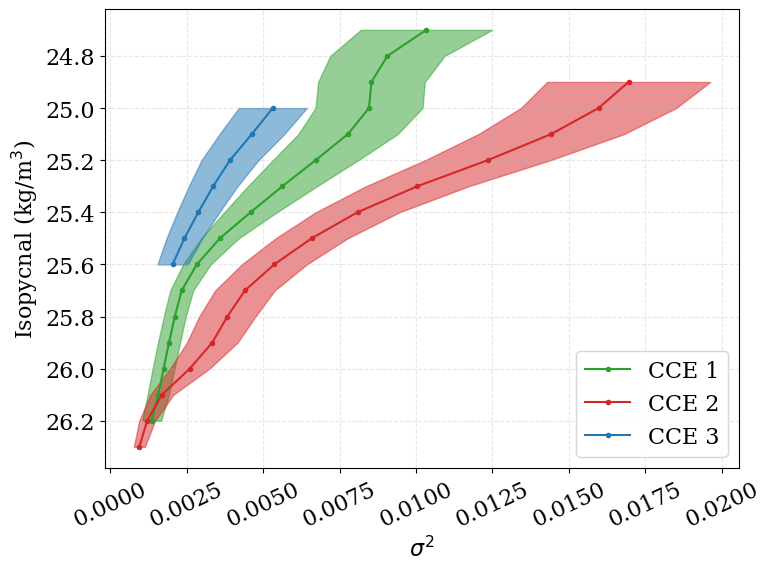

In [10]:
# Create figure
fig,ax = plt.subplots(1,1,figsize=(8, 6))

# Plot mean profiles for each mooring
ax.plot(var_profile1,iso1,'.-',color='tab:green',label='CCE 1')
ax.plot(var_profile2,iso2,'.-',color='tab:red',label='CCE 2')
ax.plot(var_profile3,iso3,'.-',color='tab:blue',label='CCE 3')

# Plot standard error of the mean profiles for each mooring
ax.fill_betweenx(iso1, var_profile1 - stdv1_profile, var_profile1 + stdv1_profile, color='tab:green', alpha=0.5)
ax.fill_betweenx(iso2, var_profile2 - stdv2_profile, var_profile2 + stdv2_profile, color='tab:red', alpha=0.5)
ax.fill_betweenx(iso3, var_profile3 - stdv3_profile, var_profile3 + stdv3_profile, color='tab:blue', alpha=0.5)

# Set axis attributes
ax.set_xlabel(r'$\sigma^2$')
ax.set_ylabel(r"Isopycnal (kg/m$^{3}$)")
ax.tick_params(axis='x',rotation=25)
ax.invert_yaxis()
ax.legend()
ax.grid(True,linestyle='--',alpha=0.3)

# Show figure
plt.tight_layout()
plt.show()

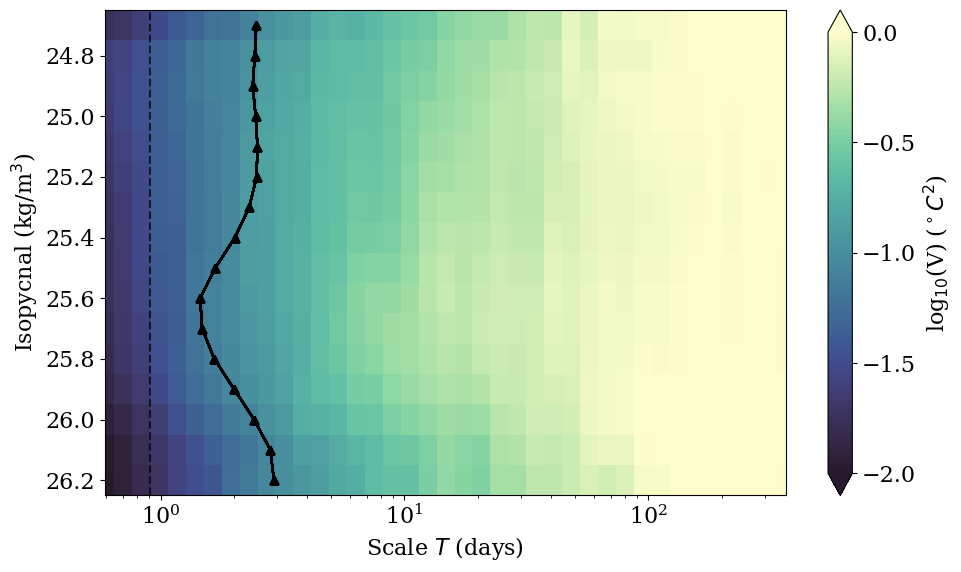

In [11]:
# Multiply the decorrelation scale by pi so that it is comparable to the period of a signal
T = Lt1_days_m

# Compute its associated frequency in units of cpd and multiply by 
f_decor = (1/T)*(2*np.pi)

# Compute the interial period in units of cpd
omega = (7.2921*10**(-5))/(2*np.pi)                   # Units: Hz 
f_inertial = 2*omega*np.sin(np.deg2rad(lat[0]))*(86400)  # Units: cpd

# Set colormap and levels
cmap = cmo.deep_r
levels= np.arange(-2,2+0.05,0.05)

# Create the figure
fig = plt.figure(figsize=(10, 6))

#--- Subplot #1 ---# 
ax1 = fig.add_subplot(111)

# Create meshgrid and zeros surface 
SC, I = np.meshgrid(scales_days, iso1)  

# Plot autocorrelation surface
contour = ax1.pcolormesh(SC,I,np.log10(V1.T),cmap=cmap,shading='auto')

# Overlay decorrelation frequency markers
ax1.plot(1/f_decor, I, 'k^-', markersize=6, label=r'$f_L = \frac{2\pi}{L_T}$')

# Plot the inertial frequency lines and text
ax1.axvline(1/f_inertial, color='k', linestyle='--', alpha=0.7, label=r'$f_{inertial}$')

# Set figure attributes
ax1.set_xlabel(r'Scale $T$ (days)')
ax1.set_ylabel(r'Isopycnal (kg/m$^3$)')
ax1.set_xscale('log')
ax1.set_xlim(scales_days[1],scales_days[-1])
#ax1.legend(loc='upper right',fontsize=10)

# Set color bar
cbar = fig.colorbar(contour,extend='both')
cbar.set_ticks(np.arange(-2,0+0.5,0.5)) 
cbar.set_label(r'log$_{10}$(V) ($^\circ C^2$) ')
contour.set_clim(-2,0)

# Reverse the direction of the x-axis 
ax1.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

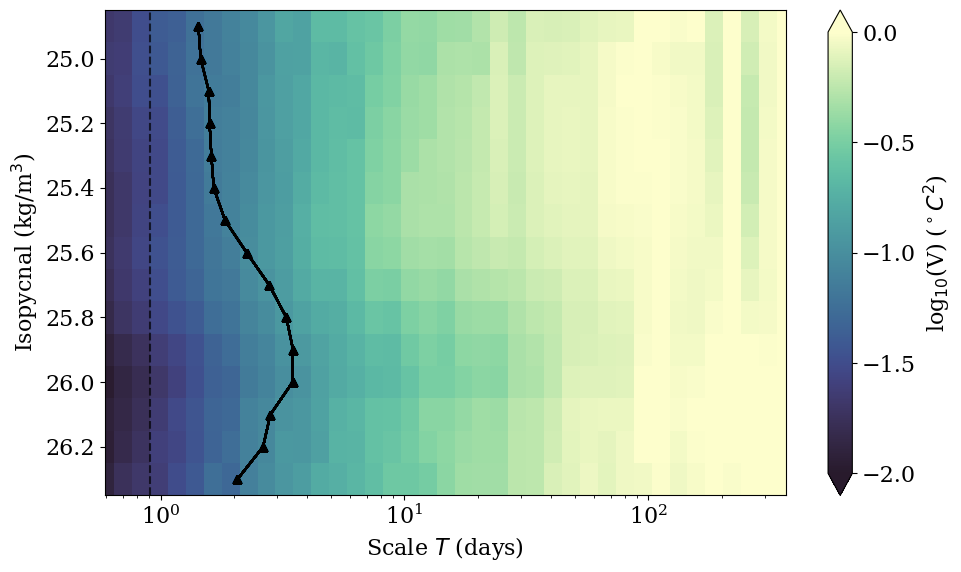

In [12]:
# Multiply the decorrelation scale by pi so that it is comparable to the period of a signal
T = Lt2_days_m

# Compute its associated frequency in units of cpd and multiply by 
f_decor = (1/T)*(2*np.pi)

# Set colormap and levels
cmap = cmo.deep_r
levels= np.arange(-2,2+0.05,0.05)

# Create the figure
fig = plt.figure(figsize=(10, 6))

#--- Subplot #1 ---# 
ax1 = fig.add_subplot(111)

# Create meshgrid and zeros surface 
SC, I = np.meshgrid(scales_days, iso2)  

# Plot autocorrelation surface
contour = ax1.pcolormesh(SC,I,np.log10(V2.T),cmap=cmap,shading='auto')

# Overlay decorrelation frequency markers
ax1.plot(1/f_decor, I, 'k^-', markersize=6, label=r'$f_L = \frac{2\pi}{L_T}$')

# Plot the inertial frequency lines and text
ax1.axvline(1/f_inertial, color='k', linestyle='--', alpha=0.7, label=r'$f_{inertial}$')

# Set figure attributes
ax1.set_xlabel(r'Scale $T$ (days)')
ax1.set_ylabel(r'Isopycnal (kg/m$^3$)')
ax1.set_xscale('log')
ax1.set_xlim(scales_days[1],scales_days[-1])
#ax1.legend(loc='upper right',fontsize=10)

# Set color bar
cbar = fig.colorbar(contour,extend='both')
cbar.set_ticks(np.arange(-2,0+0.5,0.5)) 
cbar.set_label(r'log$_{10}$(V) ($^\circ C^2$) ')
contour.set_clim(-2,0)

# Reverse the direction of the x-axis 
ax1.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

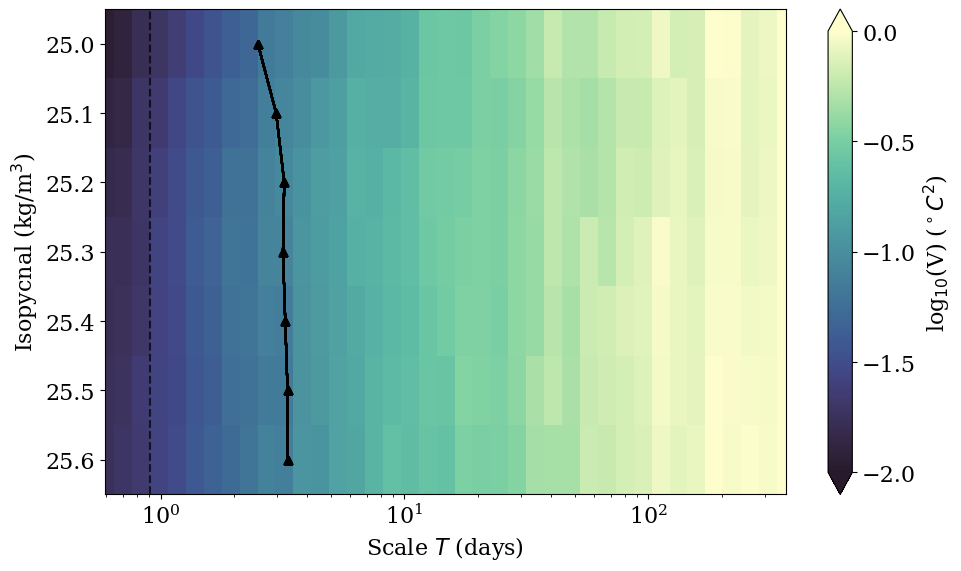

In [13]:
# Multiply the decorrelation scale by pi so that it is comparable to the period of a signal
T = Lt3_days_m

# Compute its associated frequency in units of cpd and multiply by 
f_decor = (1/T)*(2*np.pi)

# Set colormap and levels
cmap = cmo.deep_r
levels= np.arange(-2,2+0.05,0.05)

# Create the figure
fig = plt.figure(figsize=(10, 6))

#--- Subplot #1 ---# 
ax1 = fig.add_subplot(111)

# Create meshgrid and zeros surface 
SC, I = np.meshgrid(scales_days, iso3)  

# Plot autocorrelation surface
contour = ax1.pcolormesh(SC,I,np.log10(V3.T),cmap=cmap,shading='auto')

# Overlay decorrelation frequency markers
ax1.plot(1/f_decor, I, 'k^-', markersize=6, label=r'$f_L = \frac{2\pi}{L_T}$')

# Plot the inertial frequency lines and text
ax1.axvline(1/f_inertial, color='k', linestyle='--', alpha=0.7, label=r'$f_{inertial}$')

# Set figure attributes
ax1.set_xlabel(r'Scale $T$ (days)')
ax1.set_ylabel(r'Isopycnal (kg/m$^3$)')
ax1.set_xscale('log')
ax1.set_xlim(scales_days[1],scales_days[-1])
#ax1.legend(loc='upper right',fontsize=10)

# Set color bar
cbar = fig.colorbar(contour,extend='both')
cbar.set_ticks(np.arange(-2,0+0.5,0.5)) 
cbar.set_label(r'log$_{10}$(V) ($^\circ C^2$) ')
contour.set_clim(-2,0)

# Reverse the direction of the x-axis 
ax1.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

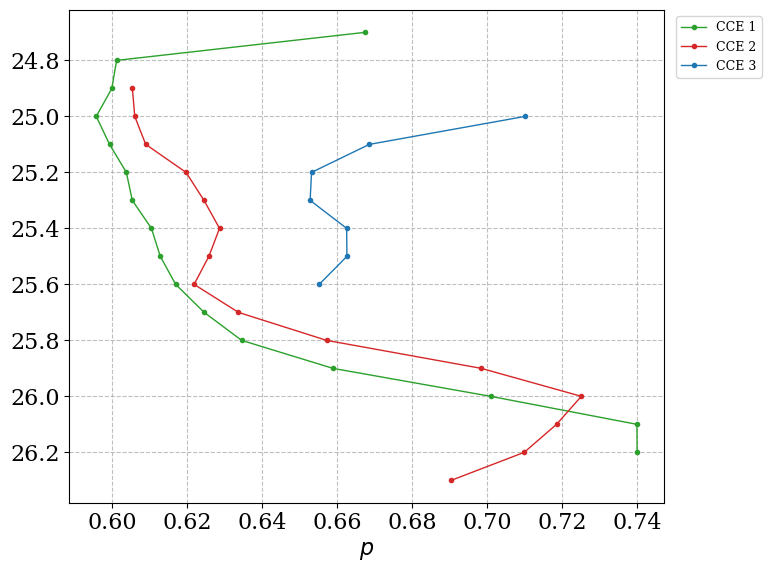

In [14]:
# Mask fill values (zeros)
p1_m = np.ma.masked_where(p1 == 0, p1)
p2_m = np.ma.masked_where(p2 == 0, p2)
p3_m = np.ma.masked_where(p3 == 0, p3)

# Create the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Plot the depth-dependent decorrelation time scale
ax.plot(p1_m, iso1, '.-', color='tab:green', linewidth=1,label='CCE 1')
ax.plot(p2_m, iso2, '.-', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(p3_m, iso3, '.-', color='tab:blue', linewidth=1, label='CCE 3')

# Set figure attributes
ax.set_xlabel(r'$p$')
ax1.set_ylabel(r'Isopycnal (kg/m$^3$)')
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Reverse the direction of the x-axis 
ax.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

In [15]:
# Check if file exists, then delete it
file_path = PATH + "mitgcm_" + option_var + "_temporal_scale_on_sig_data.npz"
if os.path.exists(file_path):
    os.remove(file_path)

# Set metadata
metadata = {
    'description': 'Temporal decorrelation scale analysis of MITgcm ' + option_var + ' profile in isopycnal coordinates time series at the three CCE mooring locations. Here, the annual and semi-annual cycles are removed before computing the decorrelation scale.',
    'source': 'MITgcm model output',
    'coordinates units': '1 hr'
}

# Save data arrays and metadata to a .npz file
np.savez(file_path, 
        autocorr1         = autocorr1,
        autocorr2         = autocorr2,
        autocorr3         = autocorr3,
        time_scale1       = time_scale1,     # Units: seconds
        time_scale2       = time_scale2,     # Units: seconds
        time_scale3       = time_scale3,     # Units: seconds
        Lt1               = Lt1_days_m,      # Units: days
        Lt2               = Lt2_days_m,      # Units: days
        Lt3               = Lt3_days_m,      # Units: days
        V1                = V1,              # Units: units^2
        V2                = V2, 
        V3                = V3,
        p1                = p1,              # Units: unitless
        p2                = p2, 
        p3                = p3,
        L1                = L1,              # Units: Days
        L2                = L2, 
        L3                = L3,
        mean_profile1     = mean_profile1, 
        mean_profile2     = mean_profile2, 
        mean_profile3     = mean_profile3, 
        stdm1_profile     = stdm1_profile, 
        stdm2_profile     = stdm2_profile, 
        stdm3_profile     = stdm3_profile, 
        var_profile1      = var_profile1, 
        var_profile2      = var_profile2, 
        var_profile3      = var_profile3, 
        stdv1_profile     = stdv1_profile, 
        stdv2_profile     = stdv2_profile, 
        stdv3_profile     = stdv3_profile,          
        lon               = lon,
        lat               = lat,
        iso1             = iso1,
        iso2             = iso2,
        iso3             = iso3,
        metadata          = metadata
        )